In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np  
import seaborn as sns 

In [8]:
#Understanding data 
df = pd.read_parquet("../data/cleaned_data/cleaned_products.parquet")

In [9]:
df.shape

(243, 21)

In [10]:
df.head()

,product_id,product_name,brand_name,category_name,sub_category_name,slug,thumb_image,qty,sku,price,...,offer_start_price,offer_end_price,product_type,status,is_approved,short_description,long_description,seo_title,seo_description,created_at
0,5,nestle ready meal bento box,Nestle,Grocery & Food,Instant Food,nestle-ready-meal-bento-box,uploads/2026-03-09_1773056017_69aeb0119a74a_ne...,120,nes-gro-bento-001,7,...,2026-03-01,2026-03-18,top,1,1,instant foodconvenient ready meal with balance...,nestle ready meal bento boxthis ready-to-eat m...,nestle ready meal bento box,shop nestle ready meal bento box for a quick a...,2024-03-13 11:46:12
1,6,nike summer cotton t-shirt,Nike,Fashion,T-shirt,nike-summer-cotton-t-shirt,uploads/2026-03-09_1773057158_69aeb486e0a5d_ni...,120,nik-fas-tsh-001,25,...,2026-03-02,2026-03-20,featured,1,1,summer t-shirtbreathable cotton t-shirt made f...,nike summer cotton t-shirtthis lightweight cot...,nike summer cotton t-shirt,shop nike summer cotton t-shirt with breathabl...,2024-03-16 09:34:13
2,7,selons knit sweater,Selons,Fashion,Hoodie & Sweater,selons-knit-sweater,uploads/2026-03-09_1773057566_69aeb61e8c1db_se...,90,sel-fas-swt-001,35,...,2026-03-01,2026-03-19,new_arrival,1,1,knit sweatersoft knit sweater designed for com...,selons knit sweaterthis sweater is made for co...,selons knit sweater,shop selons knit sweater with soft fabric and ...,2024-03-16 09:37:00
3,9,samsung galaxy tab s9 5g,Samsung,Mobile Phones,Tablet,samsung-galaxy-tab-s9-5g,uploads/2026-03-09_1773057876_69aeb754dc20d_sa...,35,sam-mob-tabs9-001,699,...,2026-03-01,2026-03-18,top,1,1,tablethigh performance tablet designed for ent...,samsung galaxy tab s9 5gthis tablet combines s...,samsung galaxy tab s9 5g,shop samsung galaxy tab s9 5g for entertainmen...,2024-03-16 09:43:13
4,10,xiaomi y68 smart watch,Xiaomi,Electronics,Smart Watch,xiaomi-y68-smart-watch,uploads/2026-03-09_1773064221_69aed01d51bc1_xi...,70,xia-ele-smw-001,39,...,2026-03-01,2026-03-20,featured,1,1,smart watchaffordable smart watch with fitness...,xiaomi y68 smart watchthis smart watch is desi...,xiaomi y68 smart watch,shop xiaomi y68 smart watch with fitness track...,2024-03-16 09:45:28


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         244 non-null    int64         
 1   product_name       244 non-null    object        
 2   brand_name         244 non-null    category      
 3   category_name      244 non-null    category      
 4   sub_category_name  244 non-null    category      
 5   slug               244 non-null    object        
 6   thumb_image        244 non-null    object        
 7   qty                244 non-null    int64         
 8   sku                244 non-null    object        
 9   price              244 non-null    int64         
 10  offer_price        244 non-null    int64         
 11  offer_start_price  244 non-null    datetime64[ns]
 12  offer_end_price    244 non-null    datetime64[ns]
 13  product_type       244 non-null    category      
 14  status    

In [6]:
df.describe()

,product_id,qty,price,offer_price,offer_start_price,offer_end_price,status,is_approved,created_at
count,244.000000,244.000000,244.000000,244.000000,244,244,244.0,244.0,244
mean,138.569672,71.651639,607.077869,563.758197,2026-03-07 14:03:56.065573888,2026-03-27 22:31:28.524590080,1.0,1.0,2026-01-27 05:35:10.446721024
min,5.000000,10.000000,4.000000,3.000000,2026-03-01 00:00:00,2026-03-15 00:00:00,1.0,1.0,2024-03-13 11:46:12
25%,73.750000,48.000000,30.000000,25.750000,2026-03-08 00:00:00,2026-03-28 00:00:00,1.0,1.0,2026-03-08 12:18:13.750000128
50%,134.500000,70.000000,69.000000,56.500000,2026-03-08 00:00:00,2026-03-29 00:00:00,1.0,1.0,2026-03-08 14:37:42
75%,198.250000,90.000000,429.000000,389.000000,2026-03-08 00:00:00,2026-03-29 00:00:00,1.0,1.0,2026-03-14 13:34:31
max,293.000000,160.000000,12500.000000,11800.000000,2026-03-08 00:00:00,2026-03-30 00:00:00,1.0,1.0,2026-03-14 14:56:59
std,79.196942,33.815974,1800.969160,1696.269553,NaN,NaN,0.0,0.0,NaN


In [7]:
#Separate numeric and categorical columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="category").columns
text_cols = df.select_dtypes(include="object").columns
date_cols = df.select_dtypes(include="datetime64[ns]").columns


In [8]:
#Explore numeric column 
df[num_cols].describe().T 

,count,mean,std,min,25%,50%,75%,max
product_id,244.0,138.569672,79.196942,5.0,73.75,134.5,198.25,293.0
qty,244.0,71.651639,33.815974,10.0,48.00,70.0,90.00,160.0
price,244.0,607.077869,1800.969160,4.0,30.00,69.0,429.00,12500.0
offer_price,244.0,563.758197,1696.269553,3.0,25.75,56.5,389.00,11800.0
status,244.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
is_approved,244.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0


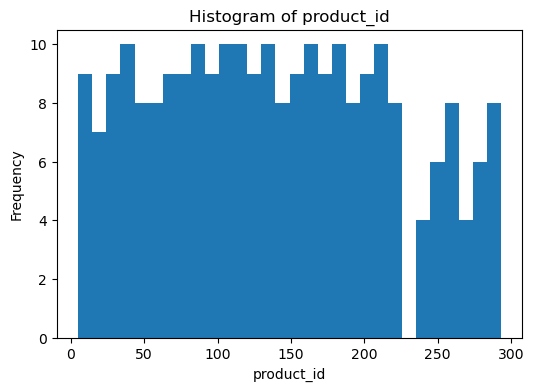

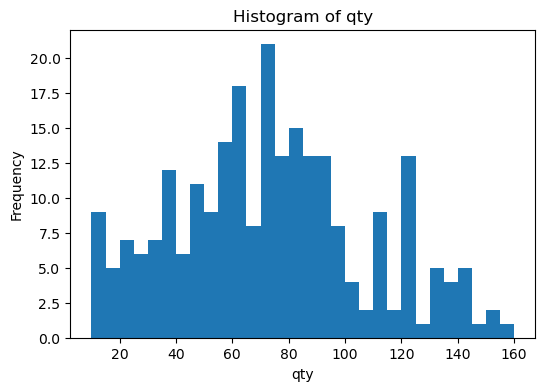

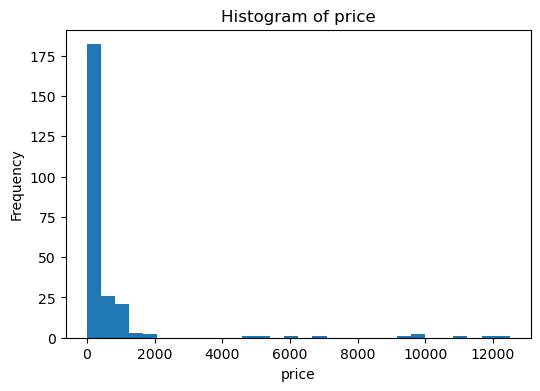

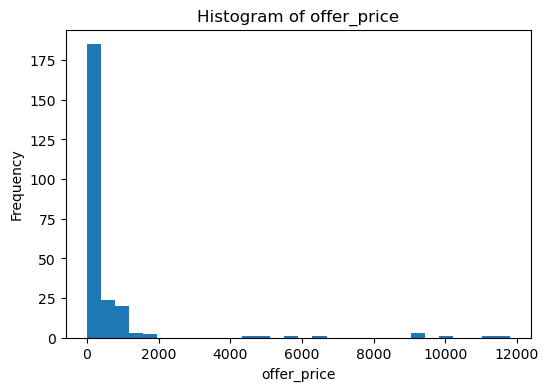

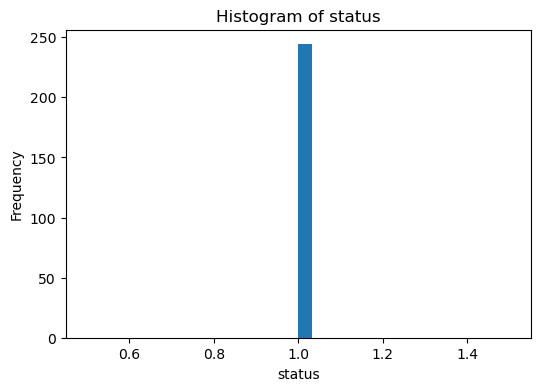

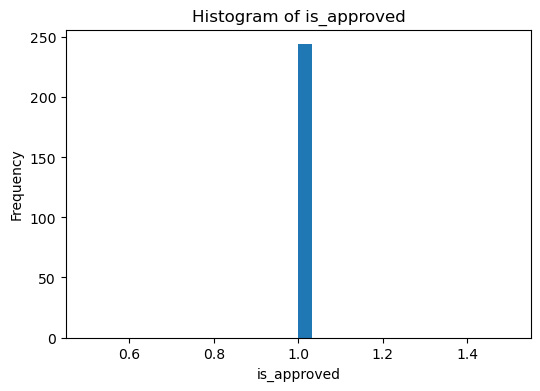

In [9]:
#Histogram: 
for col in num_cols: 
    plt.figure(figsize=(6,4)) 
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


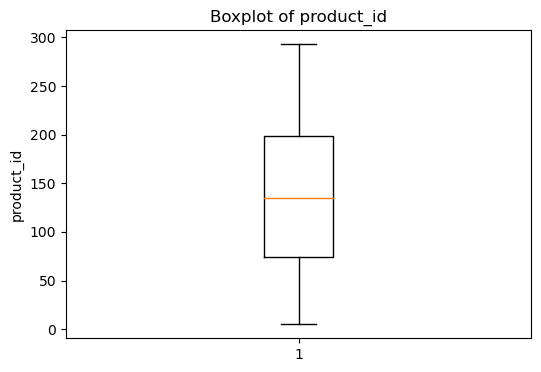

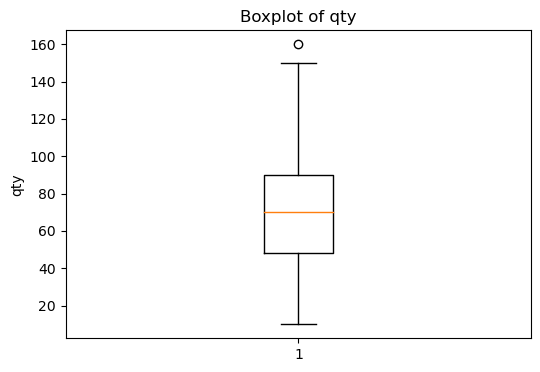

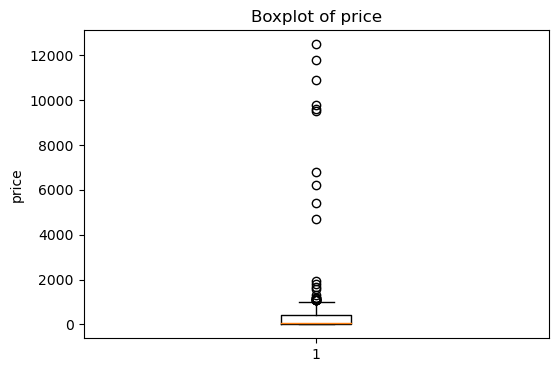

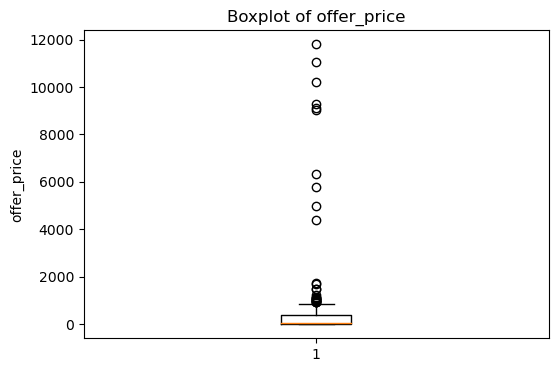

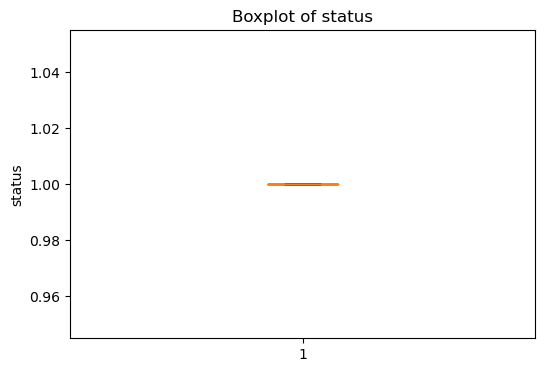

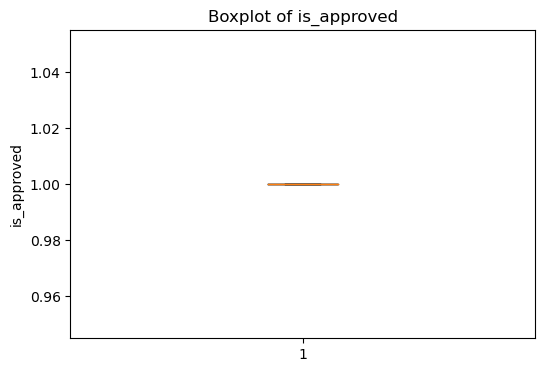

In [11]:
#Boxplots: 
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


In [13]:
#Explore the categorical column
#Frequency counts:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).head(20))



Column: brand_name
brand_name
Sony             26
Apple            26
Xiaomi           21
Under Armour     20
Pop Mart          8
Samsung           8
HP                6
Nike              6
Nestle            6
Casio             5
Rolex             5
Clinique          5
Dell              5
Lenovo            5
Asus              5
Estee Lauder      5
Selons            5
Adidas            5
Acer              4
MAC Cosmetics     4
Name: count, dtype: int64

Column: category_name
category_name
Electronics            46
Mobile Phones          46
Health & Beauty        31
Computers & Laptops    30
Watches                30
Fashion                27
Grocery & Food         20
Toys & Collectibles    14
Name: count, dtype: int64

Column: sub_category_name
sub_category_name
Phone               28
Game Disc           21
Smart Watch         21
Makeup              19
Men Watch           13
Tablet              13
Laptop              10
Plush Toys          10
Women Watch         10
Hoodie & Sweater    

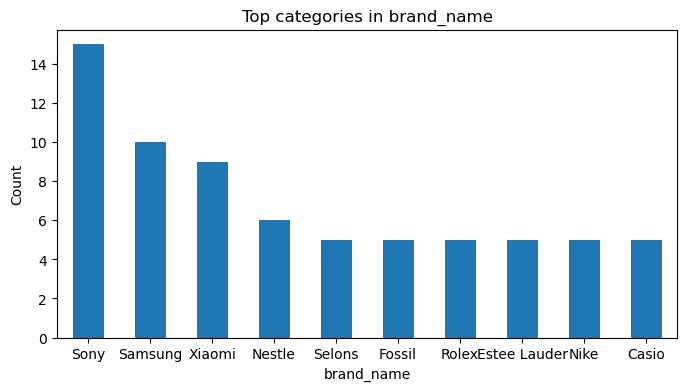

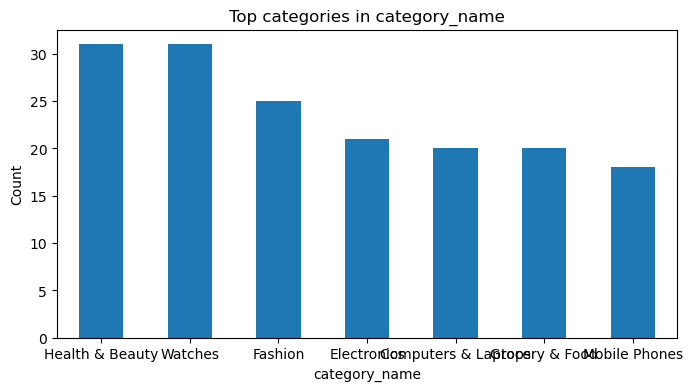

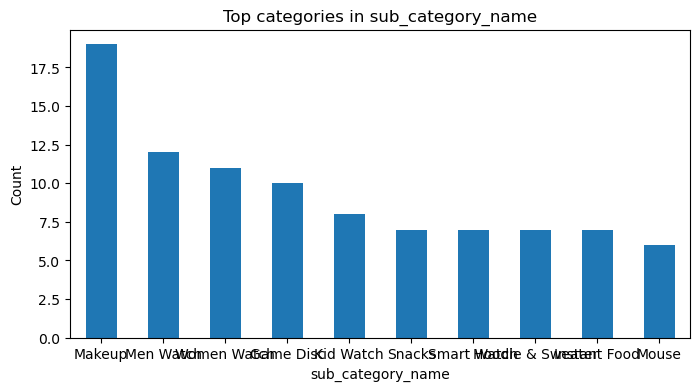

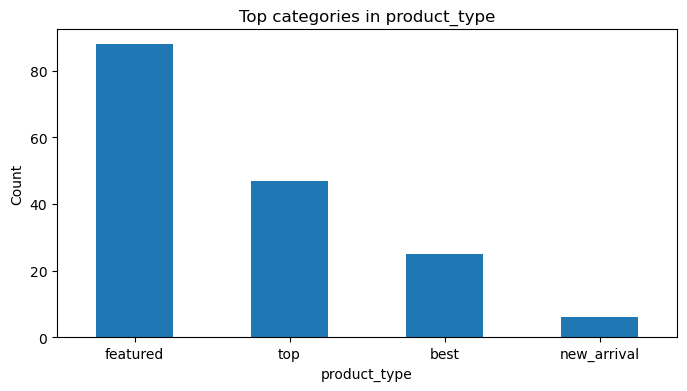

In [45]:
#Bar charts for top categories: 
for col in cat_cols:
    top_counts = df[col].value_counts(dropna=False).head(10)
    plt.figure(figsize=(8,4))
    top_counts.plot(kind="bar")
    plt.title(f"Top categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)   # ← make labels horizontal
    plt.show()

In [14]:
#Relationshops between numeric variables: 
#Corr matrix
corr = df[num_cols].corr()
corr

,product_id,qty,price,offer_price,status,is_approved
product_id,1.000000,-0.010991,0.081532,0.081824,NaN,NaN
qty,-0.010991,1.000000,-0.443531,-0.441199,NaN,NaN
price,0.081532,-0.443531,1.000000,0.999948,NaN,NaN
offer_price,0.081824,-0.441199,0.999948,1.000000,NaN,NaN
status,NaN,NaN,NaN,NaN,NaN,NaN
is_approved,NaN,NaN,NaN,NaN,NaN,NaN


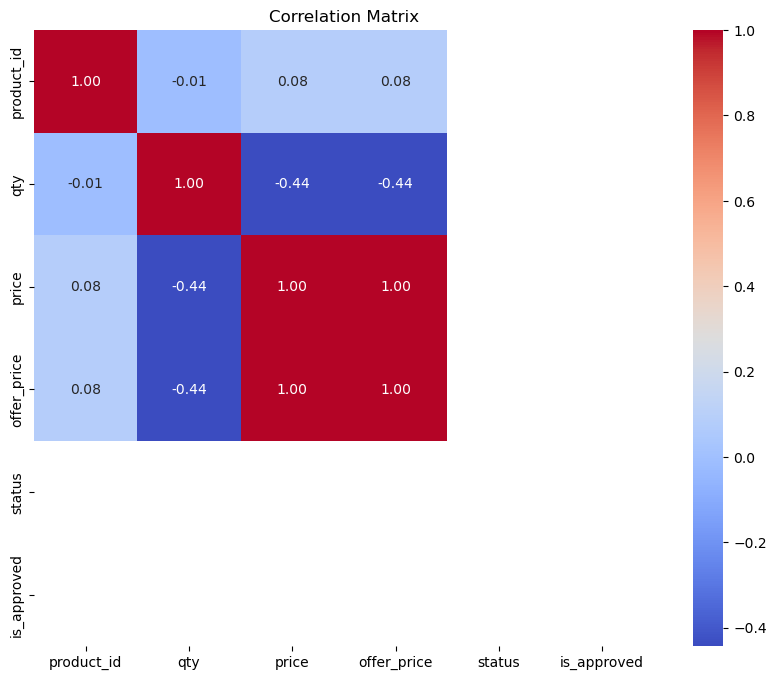

In [15]:
#Corr heatmap: 
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


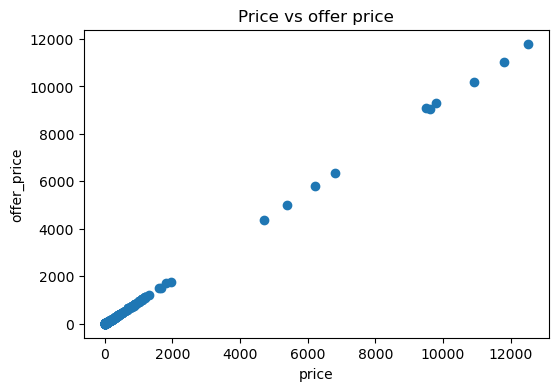

In [16]:
#Scatter: 
plt.figure(figsize=(6,4))
plt.scatter(df["price"], df["offer_price"])
plt.xlabel("price")
plt.ylabel("offer_price")
plt.title("Price vs offer price")
plt.show()


In [17]:
corr_matrix = df[num_cols].corr()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.8:
            print(corr_matrix.columns[i], "-", corr_matrix.columns[j], ":", corr)

offer_price - price : 0.9999479063499706


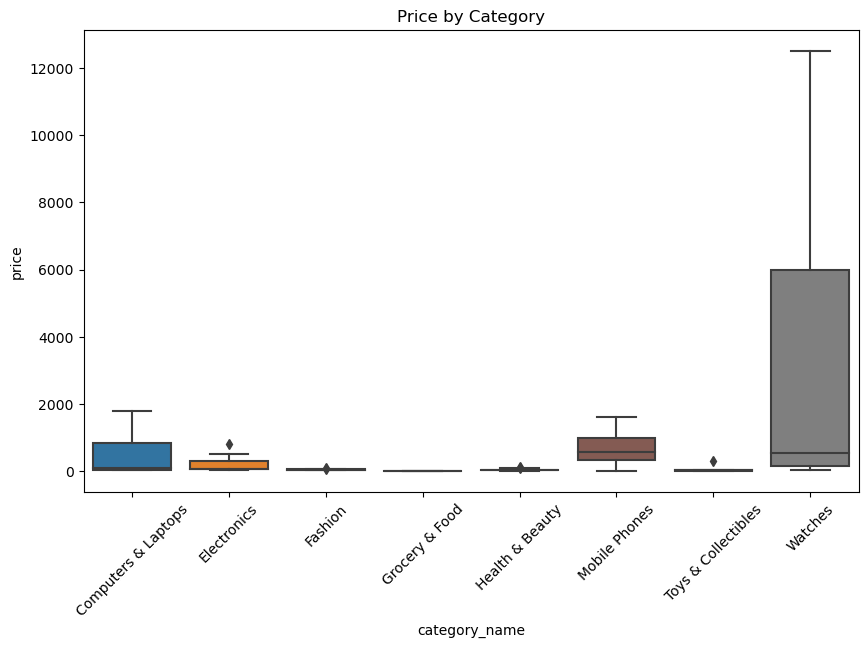

In [18]:
# Relationships between numeric and categorical values: 
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="category_name", y="price")
plt.xticks(rotation=45)
plt.title("Price by Category")
plt.show()


In [19]:
df.groupby("category_name")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
Computers & Laptops,30.0,406.500000,510.331383,24.0,36.0,99.0,836.50,1799.0
Electronics,46.0,183.608696,174.428397,21.0,59.0,79.0,294.00,799.0
Fashion,27.0,44.888889,15.280287,24.0,35.0,42.0,52.00,80.0
Grocery & Food,20.0,8.250000,5.720462,4.0,4.0,5.0,11.75,18.0
Health & Beauty,31.0,39.741935,24.321414,12.0,22.0,38.0,48.00,120.0
Mobile Phones,46.0,626.739130,389.078138,19.0,334.0,574.0,974.00,1599.0
Toys & Collectibles,14.0,41.785714,71.403704,12.0,19.0,24.5,27.75,289.0
Watches,30.0,3182.066667,4290.307416,32.0,147.5,555.0,6000.00,12500.0
